<a href="https://colab.research.google.com/github/Ibitoye07/Healthcare-Statement-Classification/blob/main/Healthcare_Statements_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Workflow Explanation

1. **Load & explore the data** — read the labeled CSV, check class balance.
2. **Build and train the models.**
3. **Evaluate both honestly on a tiny dataset** — with only 30 examples, a single train/test split would test on just a handful of statements and give a noisy, unreliable score. Instead we use **Leave-One-Out Cross-Validation (LOO-CV)**: each model is trained on 29 statements and tested on the 1 left out, repeated 30 times so every statement is used for both training and testing — without ever testing on data it was trained on.
4. **Visualize the confusion matix to see the correctly classified and misclassified samples**.
5. **Fit the final models** on all 30 labeled statements.
6. **Predict on brand-new, unseen statements**

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt
sns.set()

from google.colab import files

## Import the dataset

In [2]:
## Load dataset from Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/healthcare_statements.csv')
print(df.shape)
print()
print(df['response'].value_counts())
df.head()


(30, 2)

response
Reliable      17
Misleading    13
Name: count, dtype: int64


,statement,response
0,Malaria is transmitted through bites from infe...,Reliable
1,Drinking salt water can cure malaria,Misleading
2,Vaccines help prevent infectious diseases,Reliable
3,Antibiotics cure all viral infections,Misleading
4,Regular handwashing reduces disease transmission,Reliable


## Builidng and Training a simple AI prototype

In [4]:
# Seperate the statements from the responses
X = df['statement']
y = df['response']

loo = LeaveOneOut()

# create an empty list for the predictions
predictions = []

# loop through to maximize the dataset for training
for train_index, test_index in loo.split(X):
  X_train, X_test = X[train_index], X[test_index]
  y_train, y_test = y[train_index], y[test_index]

  '''TF-IDF (Term Frequency - Inverse Document Frequency) is a text representation
  technique that converts text into numerical features by measuring how important
  a word is in a document relative to how common it is across the entire dataset.
  TF-IDF reduces the weights of common words and increases the weights of rare important words'''

  vectorizer = TfidfVectorizer(stop_words='english')
  X_train_tfidf = vectorizer.fit_transform(X_train)
  X_test_tfidf = vectorizer.transform(X_test)



  model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
  model.fit(X_train_tfidf, y_train)

  '''The loop and the LOOCV hides a statement and trains the model on the remaining 29.
  It then repeats the process 30 times, hiding a differerent statement each time.'''

  # Making predictions on a single test set
  predictions.append(model.predict(X_test_tfidf)[0])

  '''predict() always returns a single array e.g ['Reliable'], [0] extracts the predicted value 'Reliable'
  The extracted value is added to the empty list'''

# Converts the list of predictions into a numpy array
y_pred = np.array(predictions)

#### Splitting the dataset

A train-test split is not used here because the dataset is small  (30 samples) and there is a need to maximize the dataset for training to achieve the best possible result. The technique Leave-One-Out Cross validation(LOOCV) is used to achieve this...Every one of the healthcare statement is used as a test set while the remaining 29 samples (N-1) are used for training

`stop='english'` filters basic filler words (is, can etc) before the vectorizer starts computing TF-IDF weights, so the model isn't wasting capacity on words that don't distinguish Reliable from Misleading.

## Model Validation using LOOCV

LOOCV accuracy: 73.33%
--------------------------------------------------------------------------------
===== Logistic Regression - Classification Report ====
              precision    recall  f1-score   support

  Misleading       0.69      0.69      0.69        13
    Reliable       0.76      0.76      0.76        17

    accuracy                           0.73        30
   macro avg       0.73      0.73      0.73        30
weighted avg       0.73      0.73      0.73        30

--------------------------------------------------------------------------------


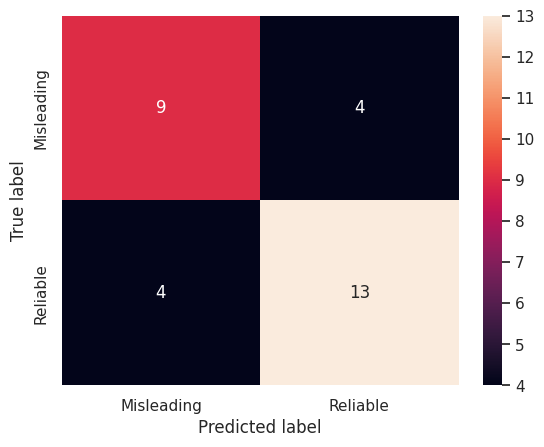

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅Downloaded successfully


In [5]:
accuracy = accuracy_score(y, y_pred)
print (f'LOOCV accuracy: {accuracy:.2%}')
print('----'*20)
print('===== Logistic Regression - Classification Report ====')


# Evaluating the models performance using LOOOCV
print(classification_report(y, y_pred))
print('----'*20)

# confusion matrix
labels_sorted = sorted(set(y))
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels= labels_sorted, yticklabels=labels_sorted)
plt.ylabel('True label')
plt.xlabel('Predicted label')
#plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

files.download('confusion_matrix.png')
print('✅Downloaded successfully')

## Train the final prototype on all the labelled data

Training the model on all the data samples to maxmize learning

In [6]:
lr_vectorizer = TfidfVectorizer(stop_words='english')
X = lr_vectorizer.fit_transform(X)
final_model = LogisticRegression(max_iter =1000, class_weight='balanced', random_state=42)
final_model.fit(X, y)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## Testing the trained prototype on new healthcare statements

To see the effectiveness of the model in classifying healthcare statements, it is important to test the prototype on new sets of statements

In [8]:
new_statements = [
    'Taking too much paracetamol can damage the liver',
    'Eating only ginger and lemon can cure typhoid fever',
    'Children under five should be fully vaccinated according to schedule',
    'Rubbing toothpaste on a burn wound speeds up healing',
    'Regular blood pressure checks help detect hypertension early',
    'COVID-19 can be cured by drinking hot water with chili pepper',
    'Sleeping under treated mosquito nets reduce the risk of malaria transmission',
    'Bleach can be safely consumed to disinfect the body internally',
    'Getting enough sleep each night supports immune function and overall health',
    'Sitting too close to a television permanently damages eyesight',
]

y_true= ['Reliable', 'Misleading', 'Reliable', 'Misleading', 'Reliable', 'Misleading', 'Reliable',
                       'Misleading', 'Reliable', 'Misleading']

X_test = lr_vectorizer.transform(new_statements)

# Making predictions on the test set
y_predictions = final_model.predict(X_test)

accuracy = accuracy_score(y_true, y_predictions)

# Prediction examples on a table
results = pd.DataFrame({
    'healthcare statement': new_statements,
    'prediction': y_predictions
})

pd.set_option('display.max_colwidth', None)

# save the predicted examples as a csv file
results.to_csv('Predicted_examples.csv', index =False)
results


,healthcare statement,prediction
0,Taking too much paracetamol can damage the liver,Misleading
1,Eating only ginger and lemon can cure typhoid fever,Misleading
2,Children under five should be fully vaccinated according to schedule,Reliable
3,Rubbing toothpaste on a burn wound speeds up healing,Misleading
4,Regular blood pressure checks help detect hypertension early,Reliable
5,COVID-19 can be cured by drinking hot water with chili pepper,Misleading
6,Sleeping under treated mosquito nets reduce the risk of malaria transmission,Reliable
7,Bleach can be safely consumed to disinfect the body internally,Misleading
8,Getting enough sleep each night supports immune function and overall health,Reliable
9,Sitting too close to a television permanently damages eyesight,Misleading


### Evaluation of the final model on Unseen Statements

              precision    recall  f1-score   support

  Misleading       0.83      1.00      0.91         5
    Reliable       1.00      0.80      0.89         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10



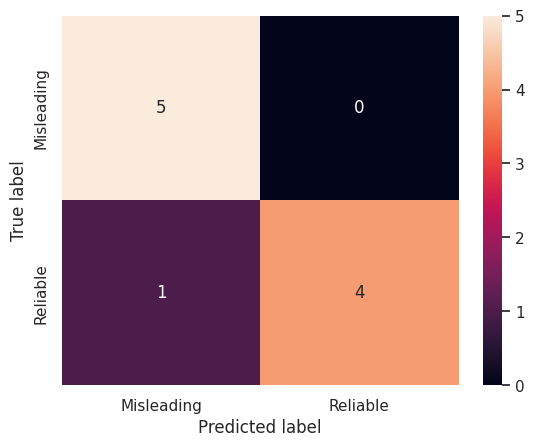

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅Downloaded successfully


In [9]:
# classification report
print(classification_report(y_true, y_predictions))


# confusion matrix
labels_sorted = sorted(set(y_true))
cm2 = confusion_matrix(y_true, y_predictions)
sns.heatmap(cm2, annot=True, fmt='d', xticklabels= labels_sorted, yticklabels=labels_sorted)
plt.ylabel('True label')
plt.xlabel('Predicted label')
#plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

files.download('confusion_matrix.png')
print('✅Downloaded successfully')

## How confident is the final model on predictions

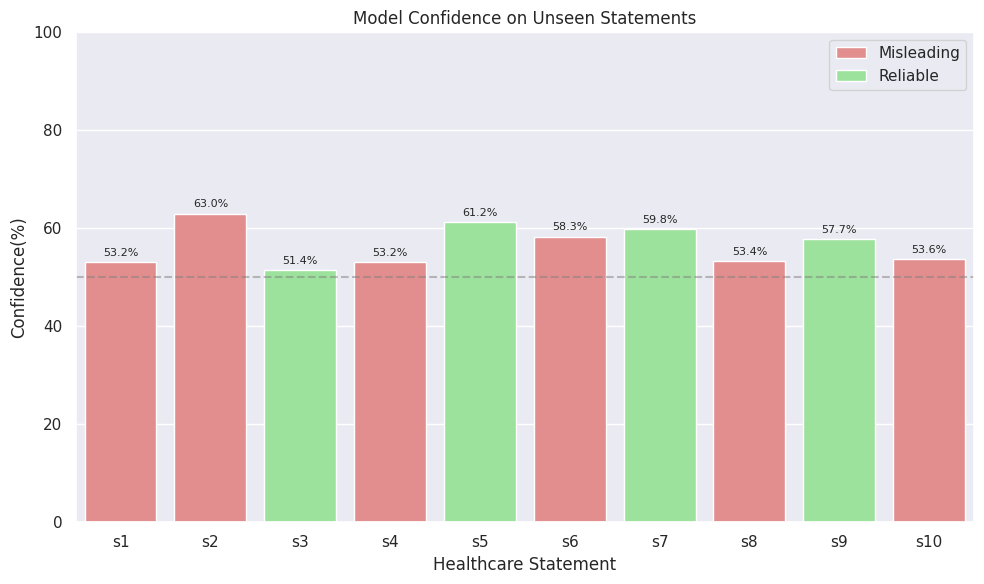

In [ ]:
# Get confidence levels
y_proba = final_model.predict_proba(X_test)

# color
palette={'Reliable':'#90EE90', 'Misleading': '#F08080'}

# represent each statement by s+1
statement = [f's{i+1}' for i in range(len(new_statements))]

# create a data frame for seaborn to reference
df= pd.DataFrame({
    'Healthcare Statement': statement,
    'Predictions': y_predictions,
    'confidence': y_proba.max(axis=1)*100
})

# plot

plt.figure(figsize=(10,6))
ax= sns.barplot(data=df, x= 'Healthcare Statement', y='confidence', hue='Predictions', palette=palette)
plt.ylabel('Confidence(%)')
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
plt.ylim(0, 100)
plt.title('Model Confidence on Unseen Statements')

# Add confidence values above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=3)

plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('model_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

files.download('model_confidence.png')
print('✅Downloaded successfully')

## Conclusion
The final prototype was tested on 10 new healthcare statements that were not part of the training data. It correctly classified 9 out of the 10 statements, showing that it can generally distinguish between reliable and misleading healthcare claims.

However, it incorrectly labelled the statement “**Taking too much paracetamol can damage the liver”** as `Misleading`, even though this is a medically `Reliable` statement. This may be because the prototype was trained on a small dataset and therefore had limited examples of warning statements related to caution, health risks or side effects. Therefore, the prototype interpretes cautionary words **'too much'** and **'damage'** to be associated with misinformation rather than medical accurate warning statements.

Overall, the results suggest that the prototype performs well as a simple proof-of-concept, but its performance could be improved by training it on a larger and more diverse set of healthcare statements.

## Save final model

In [ ]:
import joblib


# save the fitted vectorizer
joblib.dump(lr_vectorizer_final, "tfidf_vectorizer.pkl")

# save the trained logistic regression model
joblib.dump(final_model, "healthcare_lr_model.pkl")

# download the saved files
from google.colab import files

files.download("tfidf_vectorizer.pkl")
files.download("healthcare_lr_model.pkl")




<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>